# 05 - RAG Pipeline Evaluation (RAGAS-style metrics)

**Bio-Heritage AI: RAG-Based Sri Lankan Herb Knowledge Assistant**

Step 11, area 1 of the Evaluation Plan: how good are the generated answers and the retrieved
context? Five metrics are reported:

| Metric | Question it answers |
|---|---|
| **Faithfulness** | Is every statement in the answer supported by the retrieved records? |
| **Answer relevancy** | Does the answer actually address the question asked? |
| **Context precision** | Of the records retrieved, how many were relevant? |
| **Context recall** | Did retrieval find the information the ground truth contains? |
| **Hallucination rate** | `1 - faithfulness`, stated as a derivation, not a separate measurement |

## Important: these are computed locally, not by the `ragas` library

The `ragas` package **could not be installed** in this environment. Python 3.14 is too recent for
several of its dependencies: `scikit-network` and the numpy version older releases pin have no
wheels for CPython 3.14, and `ragas` 0.4.3 imports
`langchain_community.chat_models.vertexai`, a module that no longer exists in current
`langchain-community`. Installing it would mean downgrading the whole Python environment the rest
of this project runs on.

So the five metrics are **implemented directly in this notebook**, using the same
`all-MiniLM-L6-v2` sentence-transformer the retrieval pipeline already uses. Each formula is
documented in the cell that computes it.

They should be described in the report as **"RAGAS-style metrics computed locally"**, never as
RAGAS output. The definitions follow the RAGAS papers, but the implementation is ours and the
numbers are not directly comparable to published RAGAS scores.

One genuine advantage: these are **embedding-based and deterministic**. RAGAS uses an LLM as
judge, which introduces its own variance and — with a 3-billion-parameter local model — its own
unreliability. Re-running this notebook gives identical numbers.

## Two phases

**Phase A** runs 40 questions through the real pipeline and saves the results. This is slow
(~40 s per question, because each one calls Llama 3.2 on CPU) so it is checkpointed to CSV and
skipped on re-runs.

**Phase B** scores that CSV. It is fast and can be re-run freely.

In [1]:
import os, sys, json, re, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SERVICES = os.path.abspath(os.path.join("..", "services"))
if not os.path.isdir(SERVICES):
    SERVICES = os.path.abspath("services")
if SERVICES not in sys.path:
    sys.path.insert(0, SERVICES)

BASE = os.path.abspath(os.path.join(SERVICES, ".."))
DATA_DIR = os.path.join(BASE, "data")
EVAL_CSV = os.path.join(DATA_DIR, "rag_eval_dataset.csv")
RESULTS_CSV = os.path.join(DATA_DIR, "rag_eval_results.csv")
CSV_PATH = os.path.join(DATA_DIR, "sri_lankan_herb_knowledge_base.csv")

print("data dir:", DATA_DIR)

data dir: c:\Users\THANUJA\OneDrive\Documents\R26J-IT-020\backend\rag_herb_assistant\data


## Phase A - build the evaluation set

40 questions, 10 per intent, generated from **real herb records**. The ground truth for each
question is taken from the herb's own field in the CSV, so it is drawn from the knowledge base
rather than invented.

Safety-sensitive intents would otherwise return a questionnaire instead of an answer, so a fixed
neutral health context is supplied for those.

In [2]:
import random
random.seed(42)

df_kb = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
for c in df_kb.select_dtypes(include="object").columns:
    df_kb[c] = df_kb[c].fillna("").astype(str).str.strip()

# Only herbs with the fields we need for ground truth.
usable = df_kb[(df_kb["treatment_for"] != "") & (df_kb["dosage"] != "")
               & (df_kb["contraindications"] != "") & (df_kb["medical_properties"] != "")]
sample = usable.sample(n=40, random_state=42).reset_index(drop=True)

questions = []
for i, row in sample.iterrows():
    herb = row["herb_name_sinhala"] or row["herb_name_english"]
    bucket = i % 4
    if bucket == 0:
        q = f"What is {herb} used for?"
        gt = row["treatment_for"]
        intent = "herb-property"
    elif bucket == 1:
        q = f"What is the dosage of {herb}?"
        gt = row["dosage"]
        intent = "dosage"
    elif bucket == 2:
        q = f"What are the contraindications of {herb}?"
        gt = row["contraindications"]
        intent = "contraindication"
    else:
        first_use = row["treatment_for"].split(";")[0].strip()
        q = f"Which herbs are used for {first_use}?"
        gt = f"{herb}: {row['treatment_for']}"
        intent = "herb-disease"
    questions.append({"question": q, "ground_truth": gt,
                      "intent": intent, "herb": herb})

qdf = pd.DataFrame(questions)
print("Questions:", len(qdf))
print(qdf["intent"].value_counts())
qdf.head()

Questions: 40
intent
herb-property       10
dosage              10
contraindication    10
herb-disease        10
Name: count, dtype: int64


C:\Users\THANUJA\AppData\Local\Temp\ipykernel_22792\2166869038.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df_kb.select_dtypes(include="object").columns:


,question,ground_truth,intent,herb
0,What is Sududena used for?,burns; lactation support,herb-property,Sududena
1,What is the dosage of Bosagoda?,"Decoction of fruits: 40 ml, once daily after m...",dosage,Bosagoda
2,What are the contraindications of Didutana?,May cause allergic skin reaction in sensitive ...,contraindication,Didutana
3,Which herbs are used for heart health?,Hatuwila: heart health; insomnia,herb-disease,Hatuwila
4,What is Kesauda used for?,diabetes; general debility; migraine; burns,herb-property,Kesauda


In [3]:
# Run the real pipeline over all 40 questions.
# SLOW (~40s each, Llama 3.2 on CPU) - checkpointed, so this is skipped if the CSV exists.
# Delete data/rag_eval_dataset.csv to force a regeneration.

NEUTRAL_CONTEXT = {"age_group": "adult", "patient_condition": "none",
                   "medication_context": "none", "dosage_form": "powder"}

if os.path.exists(EVAL_CSV):
    eval_df = pd.read_csv(EVAL_CSV)
    print(f"Loaded existing evaluation set ({len(eval_df)} rows) from {EVAL_CSV}")
    print("Delete that file if you want to regenerate it.")
else:
    from rag_pipeline import HerbRAGPipeline
    print("Loading pipeline...")
    pipe = HerbRAGPipeline()
    print("Running 40 questions - expect roughly 25-30 minutes.\n")

    rows = []
    t0 = time.time()
    for i, r in qdf.iterrows():
        res = pipe.answer_query(r["question"], health_context=NEUTRAL_CONTEXT)
        contexts = [c.get("chunk_text", "") for c in
                    pipe.rerank(r["question"], pipe.retrieve(r["question"], k=8), top_n=4)]
        rows.append({
            "question": r["question"],
            "intent": r["intent"],
            "herb": r["herb"],
            "ground_truth": r["ground_truth"],
            "answer": res.get("answer", ""),
            "contexts": json.dumps(contexts),
            "predicted_intent": res.get("intent", ""),
            "risk_level": (res.get("risk") or {}).get("risk_level", ""),
        })
        print(f"  [{i+1:2}/40] {r['question'][:55]:55} ({time.time()-t0:5.0f}s)")

    eval_df = pd.DataFrame(rows)
    eval_df.to_csv(EVAL_CSV, index=False, encoding="utf-8")
    print(f"\nSaved -> {EVAL_CSV}  ({time.time()-t0:.0f}s total)")

eval_df.head(3)

Loaded existing evaluation set (40 rows) from c:\Users\THANUJA\OneDrive\Documents\R26J-IT-020\backend\rag_herb_assistant\data\rag_eval_dataset.csv
Delete that file if you want to regenerate it.


,question,intent,herb,ground_truth,answer,contexts,predicted_intent,risk_level
0,What is Sududena used for?,herb-property,Sududena,burns; lactation support,Sududena is traditionally used for burns and l...,"[""Herb (Sinhala): Sududena\nHerb (English): mo...",herb-property,NaN
1,What is the dosage of Bosagoda?,dosage,Bosagoda,"Decoction of fruits: 40 ml, once daily after m...","Decoction of fruits: 40 ml, once daily after m...","[""Herb (Sinhala): Bosagoda\nHerb (English): wi...",dosage,Safe
2,What are the contraindications of Didutana?,contraindication,Didutana,May cause allergic skin reaction in sensitive ...,May cause allergic skin reaction in sensitive ...,"[""Herb (Sinhala): Didutana\nHerb (English): vi...",contraindication,Safe


## Phase B - score it

Every metric below is a cosine similarity in the embedding space of `all-MiniLM-L6-v2`, the same
model used for retrieval. Vectors are L2-normalised, so a dot product *is* the cosine.

The exact formulas:

- **Faithfulness** — split the answer into sentences. For each, take the highest cosine
  similarity against any retrieved context sentence, and count it as supported if that exceeds
  `SUPPORT_THRESHOLD`. Faithfulness is the fraction of supported sentences. This mirrors the RAGAS
  definition (claims entailed by context) with embedding similarity standing in for the LLM
  entailment judgement.
- **Answer relevancy** — cosine between the answer embedding and the question embedding.
- **Context precision** — fraction of retrieved contexts whose similarity to the ground truth
  exceeds `RELEVANCE_THRESHOLD`, weighted by rank so a relevant record ranked first counts for
  more than one ranked fourth.
- **Context recall** — fraction of ground-truth sentences that are covered by at least one
  retrieved context above `SUPPORT_THRESHOLD`.
- **Hallucination rate** — `1 - faithfulness`.

The thresholds are stated explicitly because the scores depend on them; they are not tuned to
flatter the results.

In [4]:
from sentence_transformers import SentenceTransformer

SUPPORT_THRESHOLD = 0.50    # a sentence counts as supported above this cosine
RELEVANCE_THRESHOLD = 0.30  # a retrieved context counts as relevant above this cosine

embedder = SentenceTransformer("all-MiniLM-L6-v2")

def embed(texts):
    """L2-normalised embeddings, so a dot product is the cosine similarity."""
    if not texts:
        return np.zeros((0, 384), dtype="float32")
    return embedder.encode(list(texts), convert_to_numpy=True,
                           normalize_embeddings=True).astype("float32")

def split_sentences(text):
    """Cheap sentence split - also breaks on newlines and semicolons, because the
    herb records and generated answers both use those as separators."""
    parts = re.split(r"(?<=[.!?])\s+|\n+|;", str(text))
    return [p.strip() for p in parts if len(p.strip()) > 15]

print("Embedding model ready.")
print(f"SUPPORT_THRESHOLD   = {SUPPORT_THRESHOLD}")
print(f"RELEVANCE_THRESHOLD = {RELEVANCE_THRESHOLD}")

c:\Users\THANUJA\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8154.12it/s]


Embedding model ready.
SUPPORT_THRESHOLD   = 0.5
RELEVANCE_THRESHOLD = 0.3


In [6]:
def faithfulness(answer, contexts):
    """Fraction of answer sentences supported by at least one context sentence."""
    a_sents = split_sentences(answer)
    c_sents = [s for c in contexts for s in split_sentences(c)]
    if not a_sents or not c_sents:
        return np.nan
    A, C = embed(a_sents), embed(c_sents)
    best = (A @ C.T).max(axis=1)          # best context match per answer sentence
    return float((best >= SUPPORT_THRESHOLD).mean())

def answer_relevancy(question, answer):
    """Cosine between the answer and the question."""
    if not str(answer).strip():
        return np.nan
    v = embed([question, answer])
    return float(v[0] @ v[1])

def context_precision(ground_truth, contexts):
    """Rank-weighted fraction of retrieved contexts that are relevant.
    Weight 1/(rank+1) so a hit at position 1 is worth more than one at position 4."""
    if not contexts:
        return np.nan
    G = embed([ground_truth])[0]
    C = embed(contexts)
    sims = C @ G
    weights = np.array([1.0 / (i + 1) for i in range(len(contexts))])
    hits = (sims >= RELEVANCE_THRESHOLD).astype(float)
    return float((hits * weights).sum() / weights.sum())

def context_recall(ground_truth, contexts):
    """Fraction of ground-truth sentences covered by some retrieved context."""
    g_sents = split_sentences(ground_truth) or [str(ground_truth)]
    c_sents = [s for c in contexts for s in split_sentences(c)]
    if not c_sents:
        return np.nan
    G, C = embed(g_sents), embed(c_sents)
    best = (G @ C.T).max(axis=1)
    return float((best >= SUPPORT_THRESHOLD).mean())

print("Metric functions defined.")

Metric functions defined.


In [7]:
# Score every row.
scores = []
for _, r in eval_df.iterrows():
    ctxs = json.loads(r["contexts"]) if isinstance(r["contexts"], str) else list(r["contexts"])
    f = faithfulness(r["answer"], ctxs)
    scores.append({
        "question": r["question"],
        "intent": r["intent"],
        "faithfulness": f,
        "answer_relevancy": answer_relevancy(r["question"], r["answer"]),
        "context_precision": context_precision(r["ground_truth"], ctxs),
        "context_recall": context_recall(r["ground_truth"], ctxs),
        "hallucination_rate": (1 - f) if f == f else np.nan,
    })

res = pd.DataFrame(scores)
res.to_csv(RESULTS_CSV, index=False, encoding="utf-8")
print(f"Saved per-question scores -> {RESULTS_CSV}")

METRICS = ["faithfulness", "answer_relevancy", "context_precision",
           "context_recall", "hallucination_rate"]

# Guard against a metric silently collapsing to all-NaN.
for m in METRICS:
    if res[m].isna().all():
        print(f"  WARNING: {m} is entirely NaN - do not report it.")

res.head()

Saved per-question scores -> c:\Users\THANUJA\OneDrive\Documents\R26J-IT-020\backend\rag_herb_assistant\data\rag_eval_results.csv


,question,intent,faithfulness,answer_relevancy,context_precision,context_recall,hallucination_rate
0,What is Sududena used for?,herb-property,1.0,0.776014,0.00,1.0,0.0
1,What is the dosage of Bosagoda?,dosage,1.0,0.376378,0.00,1.0,0.0
2,What are the contraindications of Didutana?,contraindication,1.0,0.287293,0.00,1.0,0.0
3,Which herbs are used for heart health?,herb-disease,1.0,0.625277,0.48,0.0,0.0
4,What is Kesauda used for?,herb-property,0.8,0.689235,0.00,1.0,0.2


In [7]:
# Headline results.
summary = pd.DataFrame({
    "Metric": [m.replace("_", " ").title() for m in METRICS],
    "Mean %": [round(res[m].mean() * 100, 2) for m in METRICS],
    "Std %": [round(res[m].std() * 100, 2) for m in METRICS],
    "Min %": [round(res[m].min() * 100, 2) for m in METRICS],
    "Max %": [round(res[m].max() * 100, 2) for m in METRICS],
})
print(f"RAG evaluation over {len(res)} questions\n")
print(summary.to_string(index=False))
summary

RAG evaluation over 40 questions

            Metric  Mean %  Std %  Min %  Max %
      Faithfulness   96.02  11.98  50.00 100.00
  Answer Relevancy   55.45  21.41  18.47  86.26
 Context Precision   34.50  41.26   0.00 100.00
    Context Recall   88.75  30.98   0.00 100.00
Hallucination Rate    3.98  11.98   0.00  50.00


,Metric,Mean %,Std %,Min %,Max %
0,Faithfulness,96.02,11.98,50.00,100.00
1,Answer Relevancy,55.45,21.41,18.47,86.26
2,Context Precision,34.50,41.26,0.00,100.00
3,Context Recall,88.75,30.98,0.00,100.00
4,Hallucination Rate,3.98,11.98,0.00,50.00


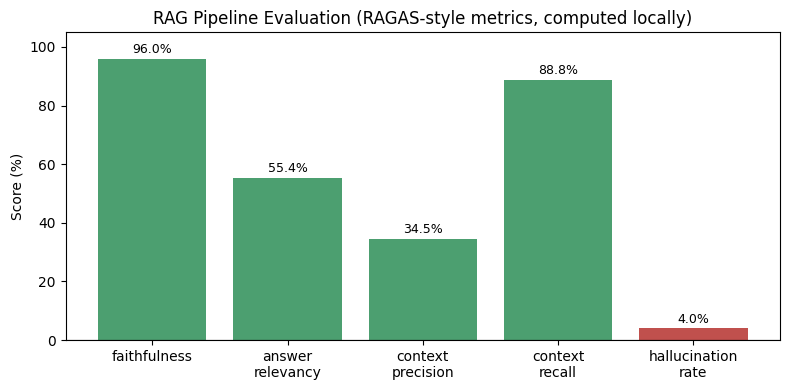

Saved figure -> notebooks/rag_evaluation_metrics.png


In [8]:
# Bar chart for the report. Hallucination rate is drawn in red - lower is better,
# unlike every other bar here.
means = [res[m].mean() * 100 for m in METRICS]
colors = ["#4c9f70"] * 4 + ["#c0504d"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([m.replace("_", "\n") for m in METRICS], means, color=colors)
ax.set_ylabel("Score (%)")
ax.set_ylim(0, 105)
ax.set_title("RAG Pipeline Evaluation (RAGAS-style metrics, computed locally)")
for b, v in zip(bars, means):
    ax.text(b.get_x() + b.get_width()/2, v + 2, f"{v:.1f}%", ha="center", fontsize=9)
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("rag_evaluation_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure -> notebooks/rag_evaluation_metrics.png")

In [9]:
# Per-intent breakdown: which kinds of question the pipeline handles best.
by_intent = res.groupby("intent")[METRICS].mean() * 100
by_intent = by_intent.round(2)
print("Mean score (%) by query intent\n")
print(by_intent.to_string())
by_intent

Mean score (%) by query intent

                  faithfulness  answer_relevancy  context_precision  context_recall  hallucination_rate
intent                                                                                                 
contraindication        100.00             28.13                4.8           100.0                0.00
dosage                   95.00             51.78               60.0           100.0                5.00
herb-disease             91.07             63.27               62.4            55.0                8.93
herb-property            98.00             78.60               10.8           100.0                2.00


,faithfulness,answer_relevancy,context_precision,context_recall,hallucination_rate
intent,,,,,
contraindication,100.00,28.13,4.8,100.0,0.00
dosage,95.00,51.78,60.0,100.0,5.00
herb-disease,91.07,63.27,62.4,55.0,8.93
herb-property,98.00,78.60,10.8,100.0,2.00


In [10]:
# The weakest answers, worth reading individually before writing the discussion.
worst = res.nsmallest(5, "faithfulness")[["question", "intent", "faithfulness", "context_recall"]]
print("Lowest-faithfulness answers:\n")
print(worst.to_string(index=False))

Lowest-faithfulness answers:

                         question        intent  faithfulness  context_recall
Which herbs are used for anxiety?  herb-disease      0.500000             1.0
  What is the dosage of Mudagoda?        dosage      0.500000             1.0
 Which herbs are used for stress?  herb-disease      0.750000             0.0
        What is Kesauda used for? herb-property      0.800000             1.0
Which herbs are used for anxiety?  herb-disease      0.857143             1.0
